# **Generating Optical Illusions from Arbitrary Prompts with Diffusion Models**

In the original work, only two specific configurations were introduced: **two-view** and **three-view** visual anagrams. The former inherently supports animation synthesis, while the latter lacks an explicit temporal framework. In our work, we extend this paradigm by proposing a **three-view animation strategy**, enabling coherent visual transitions across more complex multi-view compositions.

To generalize this framework further, we develop a pipeline that generates optical illusions from **arbitrary text prompts** under **flexible multi-view settings**. To enhance the interpretability and dynamic presentation of the generated illusions, we implement **multiple animation functions**, enabling diverse temporal interpolations between views.

However, we observe that certain transformation combinations—such as *rotation*, *flip*, *skew*, or *pixel-level permutations*—tend to degrade illusion quality, especially as the number of views increases. In fact, beyond a certain number of views, the perceptual coherence of the illusion diminishes sharply. To address this issue, we conduct a series of empirical analyses aimed at establishing a **view count threshold** and identifying **compatible transformation combinations** that preserve perceptual consistency. These insights are incorporated into our multi-view adapter design.

---

## **Part 1: View Count Threshold Estimation**

To assess the effect of view quantity on illusion fidelity, we systematically evaluate the quality of generated illusions across varying view counts. Our results indicate that illusion integrity begins to break down when the number of views exceeds four. In such cases, outputs commonly exhibit semantic drift, structural artifacts, or a breakdown in the intended perceptual effect. Based on these findings, we empirically set the **maximum reliable view count to 4** under our current architecture.

---

## **Part 2: Adaptive Enhancement for Four-View Illusion Quality**

While the four-view setting lies within the feasible range, it poses additional challenges to both semantic alignment and visual concealment. In particular, the **View4** configuration frequently underperforms in CLIP-based evaluations. To address this, we explore a suite of **adaptive sampling strategies**, including:

* **Shared seed perturbation** to introduce controlled noise that promotes diversity while maintaining view consistency;
* **Prompt fusion techniques** to enforce cross-view semantic alignment via embedding aggregation;
* **CLIP-guided view selection** to filter out visually misaligned transformations prior to final synthesis;
* **Adaptive classifier-free guidance (CFG)**, where the guidance scale is dynamically modulated based on intra-view cosine similarity, balancing the strength of text-image conditioning.

While each technique contributes positively in isolation—improving either alignment or concealment—their combination can occasionally lead to over-regularization or diminished diversity. This suggests a non-trivial **trade-off space** between consistency, diversity, and perceptual fidelity when scaling to complex multi-view setups.

---

## ⛳ **Our Contributions**

**A Generalized Prompt-to-Illusion Pipeline**
We present a diffusion-based framework capable of generating multi-view optical illusions from arbitrary text prompts, supporting both static and animated outputs.

**Empirical Upper Bound on View Count**
Through controlled experimentation, we establish four as the practical maximum number of views for maintaining coherent and perceptually plausible illusions.

**Targeted Enhancement for Challenging Configurations**
We identify and mitigate performance degradation in four-view scenarios through adaptive guidance and prompt-aware sampling strategies, improving robustness under more demanding conditions.

**Compatible Transformation Set Discovery**
We systematically evaluate view transformation combinations and recommend design patterns that preserve both semantic alignment and perceptual concealment across views.


## DeepFloyd Access

Our method uses [DeepFloyd IF](https://huggingface.co/docs/diffusers/api/pipelines/deepfloyd_if), a pixel-based diffusion model. We do not use Stable Diffusion because latent diffusion models cause artifacts in illusions (see our paper for more details).

Before using DeepFloyd IF, you must accept its usage conditions. To do so:

1. Make sure to have a [Hugging Face account](https://huggingface.co/join) and be logged in.
2. Accept the license on the model card of [DeepFloyd/IF-I-XL-v1.0](https://huggingface.co/DeepFloyd/IF-I-XL-v1.0). Accepting the license on the stage I model card will auto accept for the other IF models.
3. Log in locally by entering your [Hugging Face Hub access token](https://huggingface.co/docs/hub/security-tokens#what-are-user-access-tokens) below, which can be [found here](https://huggingface.co/settings/tokens).

In [1]:
from google.colab import drive
drive.mount('/content/drive')
FOLDERNAME = "Visual_Anagrams_2024CVPR/"
assert FOLDERNAME is not None, "[!] Enter the foldername."
import sys
sys.path.append('/content/drive/MyDrive/{}'.format(FOLDERNAME))

Mounted at /content/drive


In [ ]:
from huggingface_hub import login

token = ""
login(token=token)

## Install Dependencies

Run the below to install dependencies, including [the `visual_anagrams` repo](https://github.com/dangeng/VisualAnagrams_prerelease) which will do the heavy lifting.

In [3]:
! pip install -q \
  diffusers \
  transformers \
  safetensors \
  sentencepiece \
  accelerate \
  bitsandbytes \
  einops \
  mediapy \
  accelerate

!pip install -q git+https://github.com/dangeng/visual_anagrams.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Import Dependencies and Misc Setup

We import packages we need and define some useful functions

In [4]:
import gc
import mediapy as mp

import torch
from diffusers import DiffusionPipeline

from visual_anagrams.views import get_views
from visual_anagrams.samplers import sample_stage_1, sample_stage_2
from visual_anagrams.utils import add_args, save_illusion, save_metadata

device = 'cuda'

def im_to_np(im):
  im = (im / 2 + 0.5).clamp(0, 1)
  im = im.detach().cpu().permute(1, 2, 0).numpy()
  im = (im * 255).round().astype("uint8")
  return im


# Garbage collection function to free memory
def flush():
    gc.collect()
    torch.cuda.empty_cache()

## Load T5 TextEncoder Model
We will load the `T5` text model in half-precision (`fp16`), use it to encode some prompts, and then delete it to recover GPU memory. Note that downloading the model may take a minute or two.

If you need to further reduce memory utilization, you can also load `T5` using `8bit` quantization. Transformers directly supports [bitsandbytes](https://huggingface.co/docs/transformers/main/en/main_classes/quantization#load-a-large-model-in-8bit) through the `load_in_8bit` flag:

```python
T5EncoderModel.from_pretrained("DeepFloyd/IF-I-M-v1.0",subfolder="text_encoder", device_map="auto", load_in_8bit=True, variant="8bit")
```


In [5]:
from transformers import T5EncoderModel

text_encoder = T5EncoderModel.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    subfolder="text_encoder",
    device_map="auto",
    variant="fp16",
    torch_dtype=torch.float16,
)

pipe = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=text_encoder,  # pass the previously instantiated text encoder
    unet=None                   # do not use a UNet here, as it uses too much memory
)
print(device)

pipe = pipe.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

model.safetensors.index.fp16.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model.fp16-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/15.5k [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


cuda


##  Create Text Embeddings

We can now use the T5 model to embed prompts for our multi-view illusion. It may be a good idea to embed a few prompts that you want to use, given that we will delete the T5 text encoder in the next block. See the commented out code for an example of how to do this.

### The Art of Choosing Prompts

**Choosing prompts for illusions can be fairly tricky and unintuitive**. Many prompts simply won't make for good illusions, because they are too hard. Here are some tips:

- Styles such as "a photo of" tend to be harder as the constraint of realism is fairly difficult (but this doesn't mean they can't work!).
- Conversely, styles such as "an oil painting of" seem to do better because there's more freedom to how it can be depicted and interpreted.
- In a similar vein, subjects that allow for high degrees of flexibility in depiction tend to be good. For example, prompts such as "houseplants" or "wine and cheese" or "a kitchen"
- But be careful the subject is still easily recognizable. Illusions are much better when they are instantly understandable.
- Faces often make for very good "hidden" subjects. This is probably because the human visual system is particularly adept at picking out faces. For example, "an old man" or "marilyn monroe" tend to be good subjects.
- Perhaps a bit evident, but 3 view and 4 view illusions are considerably more difficult to get to work.
- Intuition and reasoning works less often than you would expect. Prompts that you think would work great often work poorly, and vice versa. So exploration is key.

In [6]:
views_list = [
    ['identity', 'rotate_180'],
    ['identity', 'rotate_cw'],
    ['identity', 'rotate_ccw'],
    ['identity', 'flip'],
    ['identity', 'negate'],
    ['identity', 'skew'],
    ['identity', 'patch_permute'],
    ['identity', 'pixel_permute'],
    ['identity', 'inner_circle'],
    ['identity', 'square_hinge'],
    ['identity', 'jigsaw'],
]

output_folder = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/"

# Additions
In original codes, there is not three view implementation, so I do this by myself, and this file only fit on three view configurations.

To adapt more prompts and rename the image, we fix up the following function:

In [7]:
from PIL import Image
import torchvision.transforms.functional as TF
from datetime import datetime
import os

def extract_common_prefix_suffix(prompts):
    """
    提取 prompts 中的最长公共前缀和后缀词组。
    返回：prefix, unique_parts, suffix
    """
    # 分词
    token_lists = [p.split() for p in prompts]
    min_len = min(len(tokens) for tokens in token_lists)

    # 前缀
    prefix = []
    for i in range(min_len):
        word_set = set(tokens[i] for tokens in token_lists)
        if len(word_set) == 1:
            prefix.append(token_lists[0][i])
        else:
            break

    # 后缀
    suffix = []
    for i in range(1, min_len+1):
        word_set = set(tokens[-i] for tokens in token_lists)
        if len(word_set) == 1:
            suffix.insert(0, token_lists[0][-i])
        else:
            break

    # 中间部分（unique）
    prefix_len = len(prefix)
    suffix_len = len(suffix)
    unique_parts = []
    for tokens in token_lists:
        unique = tokens[prefix_len:len(tokens)-suffix_len if suffix_len > 0 else None]
        unique_parts.append("_".join(unique))

    return "_".join(prefix), unique_parts, "_".join(suffix)

def rename_png(prompts, resolution, timestamp):
    """
    {timestamp}_{prefix}_{unique1}_{unique2}_..._{suffix}_{resolution}.png
    """
    prefix, unique_parts, suffix = extract_common_prefix_suffix(prompts)
    unique_segment = "_".join(unique_parts)
    full_name = f"{timestamp}_{prefix}_{unique_segment}"
    if suffix:
        full_name += f"_{suffix}"
    full_name += f"_{resolution}.png"
    return full_name

def create_folder(name):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    create_folder = f"{output_folder}/{name}_{timestamp}"
    os.makedirs(create_folder, exist_ok=True)
    return create_folder, timestamp

def save_image(image_tensor, prompts, resolution, timestamp, folder):
    filename = rename_png(prompts, resolution, timestamp)
    path = os.path.join(folder, filename)
    pil_img = TF.to_pil_image(image_tensor[0] / 2. + 0.5)
    pil_img.save(path)
    print(f"✅ Saved image: {path}")

## Main Diffusion Process

With our now released and available GPU memory, we can load the various DeepFloyd IF diffusion models (also at `float16` precision). This may take a minute of two.

In [102]:
from diffusers import DiffusionPipeline

# Load DeepFloyd IF stage I
stage_1 = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=None,
    variant="fp16",
    torch_dtype=torch.float16,
)
stage_1.enable_model_cpu_offload()
stage_1.to(device)

# Load DeepFloyd IF stage II
stage_2 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-II-L-v1.0",
                text_encoder=None,
                variant="fp16",
                torch_dtype=torch.float16,
              )
stage_2.enable_model_cpu_offload()
stage_2.to(device)

# Load DeepFloyd IF stage III
# (which is just Stable Diffusion 4x Upscaler)
stage_3 = DiffusionPipeline.from_pretrained(
                "stabilityai/stable-diffusion-x4-upscaler",
                torch_dtype=torch.float16
            )
stage_3.enable_model_cpu_offload()
stage_3 = stage_3.to(device)


A mixture of fp16 and non-fp16 filenames will be loaded.
Loaded fp16 filenames:
[text_encoder/model.safetensors.index.fp16.json, text_encoder/pytorch_model.bin.index.fp16.json, text_encoder/model.fp16-00002-of-00002.safetensors, safety_checker/model.fp16.safetensors, unet/diffusion_pytorch_model.fp16.safetensors, text_encoder/model.fp16-00001-of-00002.safetensors]
Loaded non-fp16 filenames:
[watermarker/diffusion_pytorch_model.safetensors
If this behavior is not expected, please check your folder structure.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components tokenizer, text_encoder, unet, scheduler, safety_checker, feature_extractor, watermarker to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.


model_index.json:   0%|          | 0.00/692 [00:00<?, ?B/s]


A mixture of fp16 and non-fp16 filenames will be loaded.
Loaded fp16 filenames:
[text_encoder/model.safetensors.index.fp16.json, text_encoder/pytorch_model.bin.index.fp16.json, text_encoder/model.fp16-00002-of-00002.safetensors, safety_checker/model.fp16.safetensors, unet/diffusion_pytorch_model.fp16.safetensors, text_encoder/model.fp16-00001-of-00002.safetensors]
Loaded non-fp16 filenames:
[watermarker/diffusion_pytorch_model.safetensors
If this behavior is not expected, please check your folder structure.


...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/221M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/982 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components vae, text_encoder, tokenizer, unet, low_res_scheduler, scheduler, safety_checker, watermarker, feature_extractor to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.


## Choose an Illusion

To generate an illusion, we need to provide a list of "views," which tell the model how to transform the image. We can get these by passing a list of strings to the `get_views` function. For a list of views and their implementation see the `views.py` file. Views inherit from the `BaseView` class, so you can implement your own views if you want.


In [9]:
def get_one_item(illusion_configs, number):
  if illusion_configs is None:
    return None, None, None
  if illusion_configs[number] is None:
    return None, None, None

  name = illusion_configs[number]["name"]
  prompts = illusion_configs[number]["prompts"]
  views = illusion_configs[number]["views"]
  v = get_views(views)
  return name, prompts, v

In [153]:
# Base data items
illusion_configs = [
    {
        "name": "four_views_rotation_objects_duck.guitar.tower.sunflower",
        "prompts": [
            "an oil painting of a duck",
            "an oil painting of a guitar",
            "an oil painting of a tower",
            "an oil painting of a sunflower"
        ],
        "views": ['identity', 'rotate_cw', 'rotate_ccw', 'rotate_180']
    },
    {
        "name": "four_views_rotation_cycle_bird.cup.cat.fox",
        "prompts": [
            "a surreal painting of a bird",
            "a surreal painting of a cup",
            "a surreal painting of a cat",
            "a surreal painting of a fox"
        ],
        "views": ["identity", "rotate_cw", "rotate_180", "rotate_ccw"]
    },
    {
        "name": "four_views_flip_symmetry_bicycle.castle.mask.sunflower",
        "prompts": [
            "a pencil sketch of a bicycle",
            "a pencil sketch of a castle",
            "a pencil sketch of a mask",
            "a pencil sketch of a sunflower"
        ],
        "views": ["identity", "flip", "rotate_180", "flip"]
    },
    {
        "name": "four_views_flip_perturbation_mountain.window.balloon.house",
        "prompts": [
            "a watercolor of a mountain",
            "a watercolor of a window",
            "a watercolor of a balloon",
            "a watercolor of a house"
        ],
        "views": ["identity", "rotate_180", "flip", "rotate_180"]
    },
    {
        "name": "four_views_mixed_flip_rotation_tree.train.lion.bridge",
        "prompts": [
            "an oil painting of a tree",
            "an oil painting of a train",
            "an oil painting of a lion",
            "an oil painting of a bridge"
        ],
        "views": ["identity", "rotate_cw", "flip", "negate"]
    },
    {
        "name": "four_views_structure_destruction_fish.microwave.pool.trafficlight",
        "prompts": [
            "a cartoon painting of a fish",
            "a cartoon painting of a microwave",
            "a cartoon painting of a swimming pool",
            "a cartoon painting of a traffic light"
        ],
        "views": ["identity", "patch_permute", "pixel_permute", "jigsaw"]
    },
    {
        "name": "four_views_style_disruptive_tornado.statue.clock.bat",
        "prompts": [
            "a digital artwork of a tornado",
            "a digital artwork of a stone statue",
            "a digital artwork of a sand clock",
            "a digital artwork of a bat"
        ],
        "views": ["identity", "negate", "square_hinge", "inner_circle"]
    },
    {
        "name": "four_views_low_high_freq_mix_robotdog.drone.rover.cannon",
        "prompts": [
            "a sci-fi painting of a robot dog",
            "a sci-fi painting of a drone",
            "a sci-fi painting of a moon rover",
            "a sci-fi painting of a laser cannon"
        ],
        "views": ["identity", "pixel_permute", "rotate_180", "patch_permute"]
    },
    {
        "name": "four_views_random_disruption_penguin.mirror.vacuum.speaker",
        "prompts": [
            "a comic-style drawing of a penguin",
            "a comic-style drawing of a mirror",
            "a comic-style drawing of a vacuum cleaner",
            "a comic-style drawing of a speaker"
        ],
        "views": ["identity", "flip", "negate", "skew"]
    },
    # view 5
    {
    "name": "five_views_extended_objects_penguin.mirror.vacuum.speaker.phone",
    "prompts": [
        "a comic-style drawing of a penguin",
        "a comic-style drawing of a mirror",
        "a comic-style drawing of a vacuum cleaner",
        "a comic-style drawing of a speaker",
        "a comic-style drawing of a mobile phone"
    ],
    "views": ["identity", "flip", "rotate_cw", "negate", "jigsaw"]
  },
    {
    "name": "five_views_rotation_cycle_bird.cup.cat.fox.umbrella",
    "prompts": [
      "a digital painting of a bird",
      "a digital painting of a cup",
      "a digital painting of a cat",
      "a digital painting of a fox",
      "a digital painting of an umbrella"
    ],
    "views": ["identity", "rotate_cw", "rotate_ccw", "flip", "skew"]
  },
  {
    "name": "five_views_flip_perturbation_mountain.window.balloon.house.tree",
    "prompts": [
      "a realistic photo of a mountain",
      "a realistic photo of a window",
      "a realistic photo of a hot air balloon",
      "a realistic photo of a house",
      "a realistic photo of a tree"
    ],
    "views": ["flip", "jigsaw", "inner_circle", "skew", "pixel_permute"]
  },
  {
    "name": "five_views_style_disruptive_tornado.statue.clock.bat.mask",
    "prompts": [
      "a watercolor painting of a tornado",
      "a watercolor painting of a statue",
      "a watercolor painting of a clock",
      "a watercolor painting of a bat",
      "a watercolor painting of a masquerade mask"
    ],
    "views": ["identity", "negate", "jigsaw", "skew", "inner_circle"]
  },
  {
    "name": "five_views_low_high_freq_mix_robotdog.drone.rover.cannon.camera",
    "prompts": [
      "a futuristic sketch of a robot dog",
      "a futuristic sketch of a drone",
      "a futuristic sketch of a lunar rover",
      "a futuristic sketch of a cannon",
      "a futuristic sketch of a security camera"
    ],
    "views": ["identity", "flip", "patch_permute", "rotate_cw", "pixel_permute"]
  },
    # view 6
    {
    "name": "six_views_extended_objects_penguin.mirror.vacuum.speaker.phone.sun",
    "prompts": [
        "a comic-style drawing of a penguin",
        "a comic-style drawing of a mirror",
        "a comic-style drawing of a vacuum cleaner",
        "a comic-style drawing of a speaker",
        "a comic-style drawing of a mobile phone",
        "a comic-style drawing of a sun"
    ],
    "views": ["identity", "flip", "rotate_cw", "negate", "jigsaw", "inner_circle"]
  },
      {
    "name": "six_views_rotation_complex_bird.cup.cat.fox.umbrella.tiger",
    "prompts": [
      "a digital painting of a bird",
      "a digital painting of a cup",
      "a digital painting of a cat",
      "a digital painting of a fox",
      "a digital painting of an umbrella",
      "a digital painting of a tiger"
    ],
    "views": ["identity", "rotate_cw", "rotate_ccw", "flip", "skew", "inner_circle"]
  },
  {
    "name": "six_views_destructive_style_fish.microwave.pool.trafficlight.bottle.sofa",
    "prompts": [
      "a surreal drawing of a fish",
      "a surreal drawing of a microwave",
      "a surreal drawing of a swimming pool",
      "a surreal drawing of a traffic light",
      "a surreal drawing of a bottle",
      "a surreal drawing of a sofa"
    ],
    "views": ["jigsaw", "negate", "flip", "rotate_cw", "patch_permute", "pixel_permute"]
  },
  {
    "name": "six_views_chaotic_scene_tree.train.lion.bridge.tunnel.sky",
    "prompts": [
      "a cinematic render of a tree",
      "a cinematic render of a train",
      "a cinematic render of a lion",
      "a cinematic render of a bridge",
      "a cinematic render of a tunnel",
      "a cinematic render of a cloudy sky"
    ],
    "views": ["identity", "flip", "inner_circle", "skew", "negate", "jigsaw"]
  },
  {
    "name": "six_views_extended_objects_rabbit.sea.sky.flag.cloud.string",
    "prompts": [
      "a comic-style drawing of a rabbit",
      "a comic-style drawing of a sea",
      "a comic-style drawing of a sky",
      "a comic-style drawing of a flag",
      "a comic-style drawing of a cloud",
      "a comic-style drawing of a string"
    ],
    "views": ["identity", "flip", "rotate_cw", "negate", "jigsaw", "inner_circle"]
  }
]


In [206]:
# view 4: 0-8; view 5: 9-13 view 6: 14-18
number = 8 # 0~len(config)-1
name, prompts, views = get_one_item(illusion_configs, number)
print(f"illusion_config_item: {number}")
print(f"name = {name}\nviews = {views}\nprompts = {prompts}")
prompt_embeds = [pipe.encode_prompt(prompt) for prompt in prompts]
prompt_embeds, negative_prompt_embeds = zip(*prompt_embeds)
prompt_embeds = torch.cat(prompt_embeds)
negative_prompt_embeds = torch.cat(negative_prompt_embeds)  # These are just null embeds

illusion_config_item: 8
name = four_views_random_disruption_penguin.mirror.vacuum.speaker
views = [<visual_anagrams.views.view_identity.IdentityView object at 0x7e363017d4d0>, <visual_anagrams.views.view_flip.FlipView object at 0x7e363017d890>, <visual_anagrams.views.view_negate.NegateView object at 0x7e363017df90>, <visual_anagrams.views.view_skew.SkewView object at 0x7e362fefbe90>]
prompts = ['a comic-style drawing of a penguin', 'a comic-style drawing of a mirror', 'a comic-style drawing of a vacuum cleaner', 'a comic-style drawing of a speaker']


In [20]:
del text_encoder
del pipe
flush()
flush()

## Generate Illusions
Now, we can sample illusions by denoising multiple views at once. The `sample_stage_1` function does this and generates a $64 \times 64$ image. The `sample_stage_2` function upsamples the resulting image while denoising all views, and generates a $256 \times 256$ image.

Finally, `stage_3` simply upsamples the $256 \times 256$ image using a single given text prompt to $1024 \times 1024$, _without_ doing multi-view denoising.

100%|██████████| 30/30 [00:02<00:00, 11.22it/s]


,,,,,

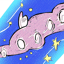
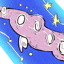
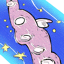
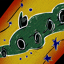
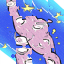
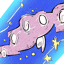

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//six_views_extended_objects_rabbit.sea.sky.flag.cloud.string_2025-05-28_08-35-22/2025-05-28_08-35-22_a_comic-style_drawing_of_a_rabbit_sea_sky_flag_cloud_string_64.png


In [171]:
image_64 = sample_stage_1(stage_1,
                          prompt_embeds,      # Replace with different prompts
                          negative_prompt_embeds,
                          views,
                          num_inference_steps=30,
                          guidance_scale=10.0,
                          reduction='mean',
                          generator=None)

# Show result
mp.show_images([im_to_np(view.view(image_64[0])) for view in views])
out_folder, timestamp = create_folder(name)
save_image(image_64, prompts, 64, timestamp, out_folder)

100%|██████████| 30/30 [00:10<00:00,  2.75it/s]


,,,,,

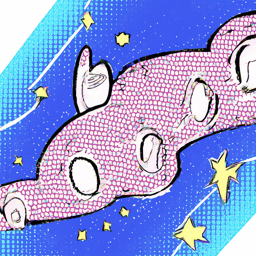
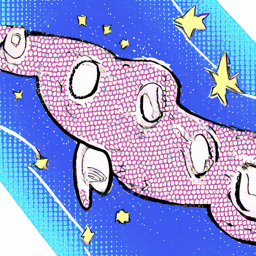
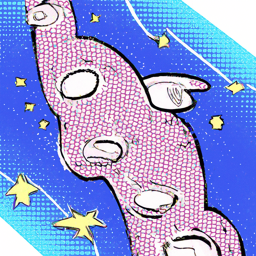
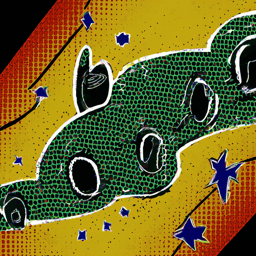
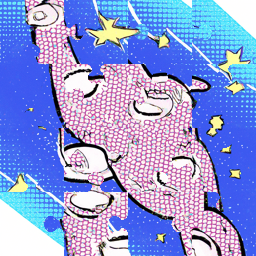
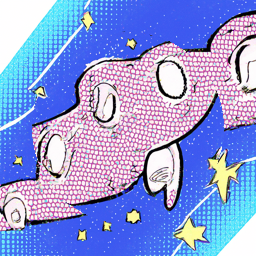

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//six_views_extended_objects_rabbit.sea.sky.flag.cloud.string_2025-05-28_08-35-22/2025-05-28_08-35-22_a_comic-style_drawing_of_a_rabbit_sea_sky_flag_cloud_string_256.png


In [172]:
image_256 = sample_stage_2(stage_2,
                           image_64,
                           prompt_embeds,      # Replace with different prompts
                           negative_prompt_embeds,
                           views,
                           num_inference_steps=30,
                           guidance_scale=10.0,
                           reduction='mean',
                           noise_level=50,
                           generator=None)

# Show result
mp.show_images([im_to_np(view.view(image_256[0])) for view in views])
save_image(image_256, prompts, 256, timestamp, out_folder)

In [173]:
image_1024 = stage_3(
                prompt=prompts[0],  # Note this is a string, and not an embedding
                image=image_256,
                noise_level=0,
                output_type='pt',
                generator=None).images
image_1024 = image_1024 * 2 - 1
save_image(image_1024, prompts, 1024, timestamp, out_folder)
# Limit display size, otherwise it's too large for most screens
mp.show_images([im_to_np(view.view(image_1024[0])) for view in views], width=400)

Output hidden; open in https://colab.research.google.com to view.

# Animating the Illusion
We design a general animation function to match N prompts and N views.
Specifically, we recommend to use highest resolution images 1024*1024.

In [135]:
import numpy as np
import imageio
from PIL import ImageDraw
from tqdm import tqdm
import torchvision.transforms.functional as TF
from visual_anagrams.utils import get_courier_font_path
from visual_anagrams.animate import easeInOutQuint, draw_text

def animate_n_view(
    im,
    views,
    prompts,
    save_video_path,
    hold_duration=90,
    text_fade_duration=10,
    transition_duration=60,
    im_size=256,
    frame_size=384,
    boomerang=True
):
    n = len(views)
    assert len(prompts) == n, f"Expected {n} prompts for {n} views."

    all_frames = []
    print(f"[INFO] Animating {n}-view sequence...")

    # Generate transition pairs: (from_idx, to_idx)
    transition_pairs = [(0, i) for i in range(1, n)]

    for from_idx, to_idx in transition_pairs:
        view = views[to_idx]
        prompt_from = prompts[from_idx]
        prompt_to = prompts[to_idx]
        label = f"{chr(65 + from_idx)} → {chr(65 + to_idx)}"

        print(f"[INFO] Generating transition {label}...")
        frames = []
        frame_1 = view.make_frame(im, 0.0)
        frame_2 = view.make_frame(im, 1.0)

        # Hold frame_1 with prompt_from
        frame_1_text = draw_text(frame_1, prompt_from, frame_size=frame_size, im_size=im_size)
        frames += [frame_1_text] * (hold_duration // 2)

        # Fade in text
        for t in np.linspace(0, 1, text_fade_duration):
            c = int(t * 255)
            frame = draw_text(frame_1, prompt_from, fill=(c, c, c), frame_size=frame_size, im_size=im_size)
            frames.append(frame)

        # Main transition frames
        for t in tqdm(np.linspace(0, 1, transition_duration), desc=f"Transition {label}"):
            t_ease = easeInOutQuint(t)
            frame = view.make_frame(im, t_ease)
            frames.append(frame)

        # Fade out text to prompt_to
        for t in np.linspace(1, 0, text_fade_duration):
            c = int(t * 255)
            frame = draw_text(frame_2, prompt_to, fill=(c, c, c), frame_size=frame_size, im_size=im_size)
            frames.append(frame)

        # Hold frame_2 with prompt_to
        frame_2_text = draw_text(frame_2, prompt_to, frame_size=frame_size, im_size=im_size)
        frames += [frame_2_text] * (hold_duration // 2)

        # Optional boomerang effect
        if boomerang:
            frames = frames + frames[::-1]

        # Cycle alignment
        frames = frames[-hold_duration//2:] + frames[:-hold_duration//2]
        all_frames.extend(frames)

    # Save animation
    # image_array = [imageio.core.asarray(frame) for frame in all_frames]
    image_array = [imageio.core.asarray(frame.convert("RGB")) for frame in all_frames]
    imageio.mimsave(save_video_path, image_array, fps=30)
    print(f"✅ Saved {n}-view animation to {save_video_path}")


In [174]:
# from visual_anagrams.animate import animate_two_view
import torchvision.transforms.functional as TF
# image = image_64
#image = image_256
image = image_1024

# Get size
im_size = image.shape[-1]
frame_size = int(im_size * 1.5)

# Make save path
save_video_path = f'{out_folder}/{timestamp}.mp4'

# Convert to PIL
pil_image = TF.to_pil_image(image[0] / 2. + 0.5)

# Make the animation
animate_n_view(
    pil_image,
    views,
    prompts,
    save_video_path=save_video_path,
    hold_duration=120,
    text_fade_duration=10,
    transition_duration=30,
    im_size=im_size,
    frame_size=frame_size,
)

# Display the video (using max width of 600 so will fit on most screens)
# mp.show_video(mp.read_video(save_video_path), fps=30, width=min(600, frame_size))

[INFO] Animating 6-view sequence...
[INFO] Generating transition A → B...


Transition A → B: 100%|██████████| 30/30 [00:02<00:00, 13.82it/s]


[INFO] Generating transition A → C...


Transition A → C: 100%|██████████| 30/30 [00:02<00:00, 11.60it/s]


[INFO] Generating transition A → D...


...

[INFO] Generating transition A → E...


Transition A → E: 100%|██████████| 30/30 [00:56<00:00,  1.90s/it]


[INFO] Generating transition A → F...


Transition A → F: 100%|██████████| 30/30 [00:01<00:00, 17.15it/s]


✅ Saved 6-view animation to /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//six_views_extended_objects_rabbit.sea.sky.flag.cloud.string_2025-05-28_08-35-22/2025-05-28_08-35-22.mp4


# Tricks For View 4
It is bad that using view 4 in current framework to generate multiple illusion images and to solve this problem, we present some tricks, try to fix up view 4 terrible performance.

In [193]:
optimized_folder = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/optimized_results/"
name_1 = "solution1_shared_seed"
name_2 = "solution2_prompt_embedding"
name_3 = "solution3_others"

In [15]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.8 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


## Solution 1
Shared Generator Seed

In [73]:
def sample_with_shared_seed(stage_1, prompt_embeds, negative_prompt_embeds, views, seed=42, noise_eps=0.05):
    # 加入微小扰动：提升多样性同时保留一致性
    generator = torch.Generator(device=stage_1.device).manual_seed(seed)

    # 添加高斯扰动
    noise = torch.randn_like(prompt_embeds) * noise_eps
    perturbed_prompts = prompt_embeds + noise

    return sample_stage_1(
        stage_1,
        perturbed_prompts,
        negative_prompt_embeds,
        views,
        num_inference_steps=30,
        guidance_scale=10.0,
        reduction='mean',
        generator=generator
    )

## Solution 2
prompt embedding

In [74]:
def sample_with_avg_prompt(stage_1, prompt_embeds, negative_prompt_embeds, views, seed=42, weights=None):
    assert prompt_embeds.shape[0] == len(views), "Prompt/view数量应一致"

    if weights is None:
        weights = torch.ones(prompt_embeds.shape[0], device=prompt_embeds.device) / prompt_embeds.shape[0]

    # reshape 权重为 [N, 1, 1] 以便广播相乘
    weights = weights.view(-1, 1, 1).to(prompt_embeds.dtype)

    # prompt_embeds shape: [N, T, D]
    fused_prompt = (prompt_embeds * weights).sum(dim=0, keepdim=True)  # [1, T, D]

    # 重复为每个 view 配一个相同 prompt
    fused_prompt = fused_prompt.expand(len(views), -1, -1)  # [N, T, D]

    generator = torch.Generator(device=stage_1.device).manual_seed(seed)

    return sample_stage_1(
        stage_1,
        fused_prompt,
        negative_prompt_embeds,
        views,
        num_inference_steps=30,
        guidance_scale=10.0,
        reduction='mean',
        generator=generator
    )


## Solution 3
Guidance

In [75]:
def generate_with_clip_guidance_shared_seed(
    stage_1,
    prompt_embeds,
    negative_prompt_embeds,
    views,
    clip_model,
    clip_tokenizer,
    clip_preprocess,
    prompts,
    threshold=0.3,
    seed=42,
):
    import torchvision.transforms as transforms
    import torch.nn.functional as F

    clip_device = next(clip_model.parameters()).device
    to_pil = transforms.ToPILImage()

    # 🔁 Step 1: 固定种子生成一组图像
    generator = torch.Generator(device=stage_1.device).manual_seed(seed)
    initial_images = sample_stage_1(stage_1, prompt_embeds, negative_prompt_embeds, views, generator=generator)

    # 🔎 Step 2: CLIP 相似度打分
    image_tensors = [view.view(initial_images[0]) for view in views]
    clip_images = [clip_preprocess(to_pil(im.cpu().clamp(0, 1))).unsqueeze(0).to(clip_device) for im in image_tensors]
    clip_images = torch.cat(clip_images)

    text_tokens = clip_tokenizer(prompts).to(clip_device)
    with torch.no_grad():
        image_features = F.normalize(clip_model.encode_image(clip_images).float(), dim=-1)
        text_features = F.normalize(clip_model.encode_text(text_tokens).float(), dim=-1)
        sims = image_features @ text_features.T

    # ✅ Step 3: 选择与 prompt 更匹配的视图
    retained_views = []
    for i, sim in enumerate(sims):
        if sim.max().item() > threshold:
            retained_views.append(views[i])

    # 📦 Step 4: 若不足视图数量，重复已有视图
    while len(retained_views) < len(views):
        retained_views.append(views[len(retained_views)])

    # 🔁 Step 5: 再次使用同一 seed 生成图像
    generator.manual_seed(seed)
    final_images = sample_stage_1(stage_1, prompt_embeds, negative_prompt_embeds, retained_views, generator=generator)

    return final_images




100%|██████████| 30/30 [00:02<00:00, 12.80it/s]


,,,

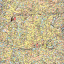
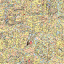
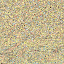
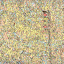

Pixel mean diff: 0.56396484375
✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//solution1_shared_seed_2025-05-28_09-11-09/2025-05-28_09-11-09_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


In [194]:
u_image_64 = sample_with_shared_seed(stage_1, prompt_embeds, negative_prompt_embeds, views)
# Show result
mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
diff = torch.abs(u_image_64[0] - image_64[0])
print("Pixel mean diff:", diff.mean().item())
sub_folder, timestamp = create_folder(name_1)
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

100%|██████████| 30/30 [00:02<00:00, 12.56it/s]


,,,

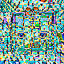
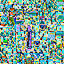
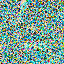
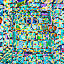

Pixel mean diff: 0.650390625
✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//solution2_prompt_embedding_2025-05-28_09-11-12/2025-05-28_09-11-12_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


In [195]:
#
u_image_64 = sample_with_avg_prompt(stage_1, prompt_embeds, negative_prompt_embeds, views)
mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
diff = torch.abs(u_image_64[0] - image_64[0])
print("Pixel mean diff:", diff.mean().item())
sub_folder, timestamp = create_folder(name_2)
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

100%|██████████| 100/100 [00:07<00:00, 12.90it/s]


,,,

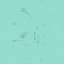
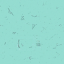
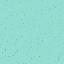
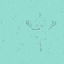

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//solution3_others_2025-05-28_09-11-30/2025-05-28_09-11-30_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


In [196]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.eval().to(device)

u_image_64 = generate_with_clip_guidance_shared_seed(
    stage_1,
    prompt_embeds,
    negative_prompt_embeds,
    views,
    clip_model,
    clip_tokenizer,
    clip_preprocess,
    prompts,
    threshold=0.3,
    seed=42,
)
mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])

# diff = torch.abs(u_image_64[0] - image_64[0])
# print("Pixel mean diff:", diff.mean().item())
sub_folder, timestamp = create_folder(name_3)
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

## Sample_stage_1 Function Comparison
| 模式                  | 说明                                     |
| ------------------- | -------------------------------------- |
| `"baseline"`        | 固定 guidance，原始 CFG                     |
| `"adaptive_soft"`   | 自适应 guidance，轻微调节（`1.0 + 0.1 * sim`）   |
| `"adaptive_strong"` | 自适应 guidance，当前你使用的（`0.8 + 0.4 * sim`） |


In [65]:
@torch.no_grad()
def sample_stage_1_with_strategy(model,
                   prompt_embeds,
                   negative_prompt_embeds,
                   views,
                   ref_im=None,
                   num_inference_steps=100,
                   guidance_scale=7.5,
                   reduction='mean',
                   generator=None,
                   strategy="baseline"):  # <- New arg

    device = torch.device('cuda')
    height = model.unet.config.sample_size
    width = model.unet.config.sample_size
    batch_size = 1
    num_prompts = prompt_embeds.shape[0]
    assert num_prompts == len(views)

    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])
    model.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = model.scheduler.timesteps

    noisy_images = model.prepare_intermediate_images(
        batch_size,
        model.unet.config.in_channels,
        height,
        width,
        prompt_embeds.dtype,
        device,
        generator,
    )

    if ref_im is not None:
        ref_im = TF.resize(ref_im, height).to(noisy_images.device).to(noisy_images.dtype)

    for i, t in enumerate(tqdm(timesteps)):
        if ref_im is not None:
            alpha_cumprod = model.scheduler.alphas_cumprod[t]
            ref_noisy = torch.sqrt(alpha_cumprod) * ref_im + \
                        torch.sqrt(1 - alpha_cumprod) * torch.randn_like(ref_im)
            ref_noisy_component = views[0].inverse_view(ref_noisy)
            noisy_images_component = views[1].inverse_view(noisy_images[0])
            noisy_images = ref_noisy_component + noisy_images_component
            noisy_images = noisy_images[None]

        viewed_noisy_images = torch.stack([v.view(noisy_images[0]) for v in views])
        model_input = torch.cat([viewed_noisy_images] * 2)
        model_input = model.scheduler.scale_model_input(model_input, t)

        noise_pred = model.unet(
            model_input,
            t,
            encoder_hidden_states=prompt_embeds,
            return_dict=False,
        )[0]

        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        def invert_stack(tensor): return torch.stack([v.inverse_view(p) for p, v in zip(tensor, views)])
        noise_pred_uncond = invert_stack(noise_pred_uncond)
        noise_pred_text = invert_stack(noise_pred_text)

        noise_pred_uncond, _ = noise_pred_uncond.split(model_input.shape[1], dim=1)
        noise_pred_text, predicted_variance = noise_pred_text.split(model_input.shape[1], dim=1)

        # Guidance strategy switch
        if strategy == "baseline":
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
        else:
            sim_weights = []
            for pred_i in noise_pred_text:
                sim_i = torch.stack([F.cosine_similarity(pred_i, pred_j, dim=0).mean()
                                     for pred_j in noise_pred_text])
                sim_weights.append(sim_i.max() if strategy == "adaptive_strong" else sim_i.mean())
            sim_weights = torch.stack(sim_weights)
            smin, smax = sim_weights.min(), sim_weights.max()
            sim_weights = (sim_weights - smin) / (smax - smin + 1e-6)

            if strategy == "adaptive_soft":
                adaptive = guidance_scale * (1.0 + 0.1 * sim_weights.view(-1, 1, 1, 1))
            elif strategy == "adaptive_strong":
                adaptive = guidance_scale * (1.0 + 0.5 * sim_weights.view(-1, 1, 1, 1))
            else:
                raise ValueError("Unknown strategy type")

            noise_pred = noise_pred_uncond + adaptive * (noise_pred_text - noise_pred_uncond)

        noise_pred = noise_pred.view(-1, num_prompts, 3, height, width)
        predicted_variance = predicted_variance.view(-1, num_prompts, 3, height, width)

        if reduction == 'mean':
            noise_pred = noise_pred.mean(1)
            predicted_variance = predicted_variance.mean(1)
        elif reduction == 'sum':
            noise_pred = noise_pred.sum(1)
            predicted_variance = predicted_variance.mean(1)
        elif reduction == 'alternate':
            noise_pred = noise_pred[:, i % num_prompts]
            predicted_variance = predicted_variance[:, i % num_prompts]
        else:
            raise ValueError("Invalid reduction")

        noise_pred = torch.cat([noise_pred, predicted_variance], dim=1)

        noisy_images = model.scheduler.step(
            noise_pred, t, noisy_images, generator=generator, return_dict=False
        )[0]

    # Final rescale to [-1, 1] to match im_to_np
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    noisy_images = noisy_images * 2 - 1
    return noisy_images


100%|██████████| 30/30 [00:02<00:00, 12.92it/s]


,,,

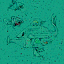
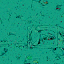
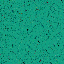
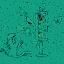

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//baseline_2025-05-28_09-11-34/2025-05-28_09-11-34_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


100%|██████████| 30/30 [00:02<00:00, 12.82it/s]


,,,

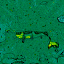
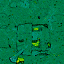
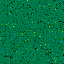
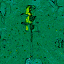

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//adaptive_soft_2025-05-28_09-11-36/2025-05-28_09-11-36_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


100%|██████████| 30/30 [00:02<00:00, 12.79it/s]


,,,

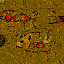
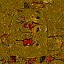
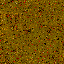
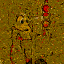

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//adaptive_strong_2025-05-28_09-11-39/2025-05-28_09-11-39_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


In [197]:
import open_clip
from PIL import Image

# Step 1: 加载 CLIP 模型
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.eval().to(device)

strategy = "baseline"
u_image_64 = sample_stage_1_with_strategy(stage_1, prompt_embeds, negative_prompt_embeds,
                                        views, num_inference_steps=30, guidance_scale=10.0,
                                        reduction='mean', strategy="baseline")

mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
sub_folder, timestamp = create_folder("baseline")
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

strategy = "adaptive_soft"
u_image_64 = sample_stage_1_with_strategy(stage_1, prompt_embeds, negative_prompt_embeds,
                                        views, num_inference_steps=30, guidance_scale=10.0,
                                        reduction='mean', strategy="baseline")

mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
sub_folder, timestamp = create_folder("adaptive_soft")
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

strategy = "adaptive_strong"
u_image_64 = sample_stage_1_with_strategy(stage_1, prompt_embeds, negative_prompt_embeds,
                                        views, num_inference_steps=30, guidance_scale=10.0,
                                        reduction='mean', strategy="baseline")

mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
sub_folder, timestamp = create_folder("adaptive_strong")
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

## Combined Version for Solution_1 and Adaptive_Soft
Actually, their performance are not better than any one of single, so:

⭕ Why Combining Prompt Perturbation (Shared Seed) and Adaptive Guidance Degrades Performance?

While both prompt perturbation and adaptive guidance independently improve image-text alignment or inter-view consistency, their combination yields significantly degraded results. We hypothesize this degradation arises due to the following incompatibilities:

1. Embedding Perturbation Increases Intra-View Variance
The shared seed strategy injects Gaussian noise into the prompt embeddings to encourage controlled diversity across generated views. However, this perturbation introduces latent inconsistencies across the views—even though they are derived from the same nominal prompt. From the perspective of the diffusion model, these perturbed embeddings encode subtly different semantic intents.

2. Adaptive Guidance Assumes Semantic Consistency
Adaptive guidance modulates the classifier-free guidance (CFG) strength per view based on their feature-space similarity. It implicitly assumes that all views should remain semantically consistent under the same prompt embedding. When this assumption is violated due to prompt perturbation, the similarity-based weighting mechanism yields lower alignment scores, resulting in reduced guidance strength for crucial views.

3. Suppressed Guidance Weakens Prompt-Image Alignment
As adaptive weights diminish due to increased view divergence, the conditional guidance signal (i.e., the influence of the prompt) becomes weaker. This leads to less faithful generations and lower CLIP alignment scores (A). In essence, the two strategies work against each other: the perturbation increases inter-view variance, while adaptive guidance penalizes such variance, leading to conflicting gradients.

4. Concealment (C) Degrades Due to View Fragmentation
Lower semantic alignment across views impairs the model's ability to generate a coherent and "concealed" semantic object across multiple images. This directly results in reduced CLIP concealment scores (C), indicating diminished multi-view coherence.

The combination of prompt perturbation and adaptive guidance results in competing inductive biases: the former encourages diversity while the latter penalizes it. This leads to under-optimized guidance weights, semantic drift, and ultimately degraded A/C performance metrics.

In [89]:
@torch.no_grad()
def sample_stage_1_shared_seed_adaptive_soft(stage_1,
                                                  prompt_embeds,
                                                  negative_prompt_embeds,
                                                  views,
                                                  seed=42,
                                                  noise_eps=0.05,
                                                  num_inference_steps=30,
                                                  guidance_scale=10.0,
                                                  reduction='mean'):
    device = stage_1.device
    generator = torch.Generator(device=device).manual_seed(seed)

    # ✅ 添加微扰
    noise = torch.randn(prompt_embeds.shape, device=device, dtype=prompt_embeds.dtype, generator=generator) * noise_eps
    perturbed_prompts = prompt_embeds + noise

    # ⚙️ diffusion init
    height = stage_1.unet.config.sample_size
    width = stage_1.unet.config.sample_size
    num_prompts = perturbed_prompts.shape[0]
    assert num_prompts == len(views)

    all_prompt_embeds = torch.cat([negative_prompt_embeds, perturbed_prompts])
    stage_1.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = stage_1.scheduler.timesteps

    noisy_images = stage_1.prepare_intermediate_images(
        1, stage_1.unet.config.in_channels, height, width,
        all_prompt_embeds.dtype, device, generator
    )

    for i, t in enumerate(tqdm(timesteps)):
        viewed_noisy_images = torch.stack([v.view(noisy_images[0]) for v in views])
        model_input = torch.cat([viewed_noisy_images] * 2)
        model_input = stage_1.scheduler.scale_model_input(model_input, t)

        noise_pred = stage_1.unet(model_input, t, encoder_hidden_states=all_prompt_embeds)[0]
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

        def invert_stack(tensor): return torch.stack([v.inverse_view(p) for p, v in zip(tensor, views)])
        noise_pred_uncond = invert_stack(noise_pred_uncond)
        noise_pred_text = invert_stack(noise_pred_text)

        noise_pred_uncond, _ = noise_pred_uncond.split(model_input.shape[1], dim=1)
        noise_pred_text, predicted_variance = noise_pred_text.split(model_input.shape[1], dim=1)

        # ✅ adaptive_soft guidance
        sim_weights = []
        for pred_i in noise_pred_text:
            sim_i = torch.stack([F.cosine_similarity(pred_i, pred_j, dim=0).mean()
                                 for pred_j in noise_pred_text])
            sim_weights.append(sim_i.mean())
        sim_weights = torch.stack(sim_weights)
        smin, smax = sim_weights.min(), sim_weights.max()
        sim_weights = (sim_weights - smin) / (smax - smin + 1e-6)

        adaptive = guidance_scale * (1.0 + 0.1 * sim_weights.view(-1, 1, 1, 1))
        noise_pred = noise_pred_uncond + adaptive * (noise_pred_text - noise_pred_uncond)

        # reduction over views
        noise_pred = noise_pred.view(-1, num_prompts, 3, height, width)
        predicted_variance = predicted_variance.view(-1, num_prompts, 3, height, width)

        if reduction == 'mean':
            noise_pred = noise_pred.mean(1)
            predicted_variance = predicted_variance.mean(1)
        elif reduction == 'sum':
            noise_pred = noise_pred.sum(1)
            predicted_variance = predicted_variance.mean(1)
        elif reduction == 'alternate':
            noise_pred = noise_pred[:, i % num_prompts]
            predicted_variance = predicted_variance[:, i % num_prompts]
        else:
            raise ValueError("Invalid reduction")

        noise_pred = torch.cat([noise_pred, predicted_variance], dim=1)

        noisy_images = stage_1.scheduler.step(noise_pred, t, noisy_images, generator=generator, return_dict=False)[0]

    # 恢复 im_to_np 兼容格式
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    noisy_images = noisy_images * 2 - 1
    return noisy_images



100%|██████████| 30/30 [00:02<00:00, 12.61it/s]


,,,

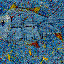
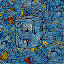
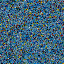
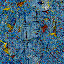

✅ Saved image: /content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends//shared_seed AND adaptive_soft_2025-05-28_09-11-41/2025-05-28_09-11-41_a_cartoon_painting_of_a_fish_microwave_swimming_pool_traffic_light_64.png


In [198]:
u_image_64 = sample_stage_1_shared_seed_adaptive_soft(
    stage_1,
    prompt_embeds=prompt_embeds,
    negative_prompt_embeds=negative_prompt_embeds,
    views=views,
    num_inference_steps=30,
    guidance_scale=10.0,
    reduction='mean',
    seed=42,
    noise_eps=0.05,
)
mp.show_images([im_to_np(view.view(u_image_64[0])) for view in views])
sub_folder, timestamp = create_folder("shared_seed AND adaptive_soft")
save_image(u_image_64, prompts, 64, timestamp, sub_folder)

# Temporary Evaluation
## Configurations
In this part, we will collect json schema data from functions and then prepare for next evaluation. (single clip and multiple clip)

Before that, you need to install open_clip_torch.


In [20]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.8 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [184]:
def get_variables(illusion_configs, number):
  if illusion_configs is None:
    return None, None, None
  if illusion_configs[number] is None:
    return None, None, None

  name = illusion_configs[number]["name"]
  prompts = illusion_configs[number]["prompts"]
  views = illusion_configs[number]["views"]
  return name, prompts, views

In [207]:
output_folder_names = [
    # 4
    "four_views_rotation_objects_duck.guitar.tower.sunflower_2025-05-27_06-55-43",
    "four_views_rotation_cycle_bird.cup.cat.fox_2025-05-27_08-23-20",
    "four_views_rotation_cycle_bird.cup.cat.fox_2025-05-27_08-27-11",
    "four_views_flip_symmetry_bicycle.castle.mask.sunflower_2025-05-27_08-31-49",
    "four_views_flip_perturbation_mountain.window.balloon.house_2025-05-27_12-28-47",
    "four_views_mixed_flip_rotation_tree.train.lion.bridge_2025-05-27_12-46-09",
    "four_views_structure_destruction_fish.microwave.pool.trafficlight_2025-05-27_13-07-08",
    "four_views_style_disruptive_tornado.statue.clock.bat_2025-05-27_13-11-00",
    "four_views_low_high_freq_mix_robotdog.drone.rover.cannon_2025-05-27_13-32-23",
    "four_views_random_disruption_penguin.mirror.vacuum.speaker_2025-05-27_14-01-00",
    # 5
    "five_views_extended_objects_penguin.mirror.vacuum.speaker.phone_2025-05-28_07-34-44",
    "five_views_rotation_cycle_bird.cup.cat.fox.umbrella_2025-05-28_08-13-37",
    "five_views_style_disruptive_tornado.statue.clock.bat.mask_2025-05-28_08-25-36",
    "five_views_flip_perturbation_mountain.window.balloon.house.tree_2025-05-28_08-23-16",
    "five_views_low_high_freq_mix_robotdog.drone.rover.cannon.camera_2025-05-28_08-27-39",
    # 6
    "six_views_extended_objects_penguin.mirror.vacuum.speaker.phone.sun_2025-05-28_08-01-00",
    "six_views_chaotic_scene_tree.train.lion.bridge.tunnel.sky_2025-05-28_08-33-02",
    "six_views_destructive_style_fish.microwave.pool.trafficlight.bottle.sofa_2025-05-28_08-31-32",
    "six_views_rotation_complex_bird.cup.cat.fox.umbrella.tiger_2025-05-28_08-30-12",
    "six_views_extended_objects_rabbit.sea.sky.flag.cloud.string_2025-05-28_08-35-22",
]

solution_names = [
    "baseline_2025-05-28_06-56-41",
    "solution1_shared_seed_2025-05-28_06-54-41",
    "solution2_prompt_embedding_2025-05-28_06-54-45",
    "solution3_others_2025-05-28_06-56-14",
    "adaptive_soft_2025-05-28_06-56-43",
    "adaptive_strong_2025-05-28_06-56-46",
    "shared_seed AND adaptive_soft_2025-05-28_07-07-24"
]

# optional
# view 4: 0-8; view 5: 9-13 view 6: 14-18
number = 8
name, prompts, views = get_variables(illusion_configs, number)
name_list = [name_1, name_2, name_3, "baseline", "adaptive_soft", "adaptive_strong", "shared_seed AND adaptive_soft"]
opt_configs = [
    {
        "name": name,
        "prompts":prompts,
        "views": views
    }
    for name in name_list
]
print("opt-configs:")
for i in opt_configs:
  print(f"item: {i}")
print("\n")

for item in output_folder_names:
  print(f"sub_folder: {item}")

opt-configs:
item: {'name': 'solution1_shared_seed', 'prompts': ['a comic-style drawing of a penguin', 'a comic-style drawing of a mirror', 'a comic-style drawing of a vacuum cleaner', 'a comic-style drawing of a speaker'], 'views': ['identity', 'flip', 'negate', 'skew']}
item: {'name': 'solution2_prompt_embedding', 'prompts': ['a comic-style drawing of a penguin', 'a comic-style drawing of a mirror', 'a comic-style drawing of a vacuum cleaner', 'a comic-style drawing of a speaker'], 'views': ['identity', 'flip', 'negate', 'skew']}
item: {'name': 'solution3_others', 'prompts': ['a comic-style drawing of a penguin', 'a comic-style drawing of a mirror', 'a comic-style drawing of a vacuum cleaner', 'a comic-style drawing of a speaker'], 'views': ['identity', 'flip', 'negate', 'skew']}
item: {'name': 'baseline', 'prompts': ['a comic-style drawing of a penguin', 'a comic-style drawing of a mirror', 'a comic-style drawing of a vacuum cleaner', 'a comic-style drawing of a speaker'], 'views': 

In [208]:
import re, os

def get_png(folder):
  all_png_paths = []
  for subdir, _, files in os.walk(folder):
      for file in files:
          if file.lower().endswith(".png"):
              full_path = os.path.join(subdir, file)
              all_png_paths.append(full_path)
  return all_png_paths

def get_config(output_folder_names, illusion_configs, output_folder):
  results = []
  for folder in output_folder_names:
      match = re.match(r"(.+)_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}", folder)
      t_folder = output_folder + folder
      png_paths = get_png(t_folder)
      if match:
          base_name = match.group(1)
          matched_config = next((cfg for cfg in illusion_configs if cfg["name"] == base_name), None)
          results.append({
              "folder": t_folder,
              "config_name": base_name,
              "matched": matched_config is not None,
              "prompts": matched_config["prompts"] if matched_config else None,
              "views": matched_config["views"] if matched_config else None,
              "images_paths": png_paths,
          })
  return results

results = get_config(output_folder_names=output_folder_names, illusion_configs=illusion_configs, output_folder=output_folder)
results_s = get_config(output_folder_names=solution_names, illusion_configs=opt_configs, output_folder=optimized_folder)
# results_o = get_config(output_folder_names=origin_names, illusion_configs=origin_configs, output_folder=optimized_folder)

if results:
  print("results:")
  for i in results:
    print(i)

if results_s:
  print("results for SOLUTION:")
  for i in results_s:
    print(i)

results:
{'folder': '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/four_views_rotation_objects_duck.guitar.tower.sunflower_2025-05-27_06-55-43', 'config_name': 'four_views_rotation_objects_duck.guitar.tower.sunflower', 'matched': True, 'prompts': ['an oil painting of a duck', 'an oil painting of a guitar', 'an oil painting of a tower', 'an oil painting of a sunflower'], 'views': ['identity', 'rotate_cw', 'rotate_ccw', 'rotate_180'], 'images_paths': ['/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/four_views_rotation_objects_duck.guitar.tower.sunflower_2025-05-27_06-55-43/2025-05-27_06-55-43_an_oil_painting_of_a_duck_guitar_tower_sunflower_64.png', '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/four_views_rotation_objects_duck.guitar.tower.sunflower_2025-05-27_06-55-43/2025-05-27_06-55-43_an_oil_painting_of_a_duck_guitar_tower_sunflower_256.png', '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/extends/four_views_rotation_objects_duck.guitar.tower.sunflower_

## CLIP for each images
To score each image after generation.

In [27]:
# CLIP For A&C
# current image path + prompt
import torch
import torchvision.transforms as T
from PIL import Image
import open_clip

def compute_clip_scores_for_each_image(image_paths, prompts, device="cuda", clip_model_name="ViT-B-32"):
    import open_clip
    from PIL import Image
    import torch
    import os

    # Load CLIP model
    model, _, preprocess = open_clip.create_model_and_transforms(
        clip_model_name, pretrained="laion2b_s34b_b79k")
    tokenizer = open_clip.get_tokenizer(clip_model_name)
    model.to(device).eval()

    # Encode prompts
    tokenized = tokenizer(prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(tokenized)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    results = []
    for image_path in image_paths:
        image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            image_feature = model.encode_image(image)
            image_feature = image_feature / image_feature.norm(dim=-1, keepdim=True)

        # Get similarity scores between image and each prompt
        sim = (image_feature @ text_features.T).squeeze(0)  # shape: [N]

        # A: worst alignment (min similarity)
        A = sim.min().item()

        # C: Concealment (softmax then sum normalized probability mass on diagonal)
        tau = 0.01
        sim_matrix = sim.unsqueeze(0)  # shape: [1, N]
        softmax_sim = torch.nn.functional.softmax(sim_matrix / tau, dim=1)  # shape: [1, N]
        C = softmax_sim.sum().item() / len(prompts)

        results.append({
            "image": os.path.basename(image_path),
            "A": round(A, 4),
            "C": round(C, 4),
        })

    return results




In [177]:
print("CLIP For Single Image：")
for entry in results:
    if not entry["matched"]:
        print(f"❌ Can't match config: {entry['config_name']}")
        continue

    image_paths = entry["images_paths"]
    prompts = entry["prompts"]

    # 计算分数
    clip_scores = compute_clip_scores_for_each_image(
        image_paths=image_paths,
        prompts=prompts,
        clip_model_name="ViT-B-32",  # 可换为 ViT-L-14 等
        device="cuda"
    )

    print(f"✅ {entry['config_name']}:")
    for i, score in enumerate(clip_scores):
        print(f"  📸 Image {i+1}: A = {score['A']:.4f}, C = {score['C']:.4f}")


CLIP For Single Image：
✅ four_views_rotation_objects_duck.guitar.tower.sunflower:
  📸 Image 1: A = 0.2396, C = 0.2500
  📸 Image 2: A = 0.2843, C = 0.2500
  📸 Image 3: A = 0.2719, C = 0.2500
✅ four_views_rotation_cycle_bird.cup.cat.fox:
  📸 Image 1: A = 0.2184, C = 0.2500
  📸 Image 2: A = 0.2476, C = 0.2500
  📸 Image 3: A = 0.2454, C = 0.2500
✅ four_views_rotation_cycle_bird.cup.cat.fox:
  📸 Image 1: A = 0.2302, C = 0.2500
  📸 Image 2: A = 0.2698, C = 0.2500
  📸 Image 3: A = 0.2700, C = 0.2500
✅ four_views_flip_symmetry_bicycle.castle.mask.sunflower:
  📸 Image 1: A = 0.2430, C = 0.2500
  📸 Image 2: A = 0.2325, C = 0.2500
  📸 Image 3: A = 0.2263, C = 0.2500
✅ four_views_flip_perturbation_mountain.window.balloon.house:
  📸 Image 1: A = 0.2450, C = 0.2500
  📸 Image 2: A = 0.2692, C = 0.2500
  📸 Image 3: A = 0.2671, C = 0.2500
✅ four_views_mixed_flip_rotation_tree.train.lion.bridge:
  📸 Image 1: A = 0.2153, C = 0.2500
  📸 Image 2: A = 0.2500, C = 0.2500
  📸 Image 3: A = 0.2325, C = 0.2500
✅

In [209]:
print("Solution For Single Image：")
for entry in results_s:
    if not entry["matched"]:
        print(f"❌ Can't match config: {entry['config_name']}")
        continue

    image_paths = entry["images_paths"]
    prompts = entry["prompts"]

    # 计算分数
    clip_scores = compute_clip_scores_for_each_image(
        image_paths=image_paths,
        prompts=prompts,
        clip_model_name="ViT-B-32",  # 可换为 ViT-L-14 等
        device="cuda"
    )

    print(f"✅ {entry['config_name']}:")
    for i, score in enumerate(clip_scores):
        print(f"  📸 Image {i+1}: A = {score['A']:.4f}, C = {score['C']:.4f}")

# 8
# Solution For Single Image：
# ✅ baseline:
#   📸 Image 1: A = 0.2393, C = 0.2500
# ✅ solution1_shared_seed:
#   📸 Image 1: A = 0.2223, C = 0.2500
# ✅ solution2_prompt_embedding:
#   📸 Image 1: A = 0.1322, C = 0.2500
# ✅ solution3_others:
#   📸 Image 1: A = 0.2353, C = 0.2500
# ✅ adaptive_soft:
#   📸 Image 1: A = 0.1719, C = 0.2500
# ✅ adaptive_strong:
#   📸 Image 1: A = 0.1839, C = 0.2500
# ✅ shared_seed AND adaptive_soft:
#   📸 Image 1: A = 0.1391, C = 0.2500

Solution For Single Image：
✅ baseline:
  📸 Image 1: A = 0.2393, C = 0.2500
✅ solution1_shared_seed:
  📸 Image 1: A = 0.2223, C = 0.2500
✅ solution2_prompt_embedding:
  📸 Image 1: A = 0.1322, C = 0.2500
✅ solution3_others:
  📸 Image 1: A = 0.2353, C = 0.2500
✅ adaptive_soft:
  📸 Image 1: A = 0.1719, C = 0.2500
✅ adaptive_strong:
  📸 Image 1: A = 0.1839, C = 0.2500
✅ shared_seed AND adaptive_soft:
  📸 Image 1: A = 0.1391, C = 0.2500


## CLIP for N*M matrix
To score N*M prompts and images pairs.

In [29]:
import torch
import open_clip
from PIL import Image
import os

def compute_clip_scores_full_matrix(image_paths, prompts, device="cuda", clip_model_name="ViT-B-32"):
    """
    Compute full CLIP similarity matrix S (N_images x N_prompts),
    and alignment/concealment scores across all.
    """
    # Load CLIP model
    model, _, preprocess = open_clip.create_model_and_transforms(
        clip_model_name, pretrained="laion2b_s34b_b79k")
    tokenizer = open_clip.get_tokenizer(clip_model_name)
    model.to(device).eval()

    # Encode prompts
    tokenized = tokenizer(prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(tokenized)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)  # [P, D]

    # Encode images
    image_tensors = []
    image_names = []
    for img_path in image_paths:
        img = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        image_tensors.append(img)
        image_names.append(os.path.basename(img_path))
    images = torch.cat(image_tensors, dim=0)  # [N, C, H, W]

    with torch.no_grad():
        image_features = model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)  # [N, D]

    # Compute similarity matrix S
    sim_matrix = image_features @ text_features.T  # [N, P]

    # A score: worst alignment among diagonal (assuming N == P or min(N, P))
    diag_len = min(sim_matrix.size(0), sim_matrix.size(1))
    diag_values = torch.diagonal(sim_matrix, 0)[:diag_len]
    A = diag_values.min().item()

    # C score: concealment (average of row and column softmax traces)
    tau = 0.01
    row_softmax = torch.nn.functional.softmax(sim_matrix / tau, dim=1)  # [N, P]
    col_softmax = torch.nn.functional.softmax(sim_matrix.T / tau, dim=1)  # [P, N]
    C_row = torch.trace(row_softmax) / row_softmax.size(0)
    C_col = torch.trace(col_softmax) / col_softmax.size(0)
    C = ((C_row + C_col) / 2).item()

    return {
        "A": round(A, 4),
        "C": round(C, 4),
        "S": sim_matrix.detach().cpu(),
        "image_names": image_names,
        "prompts": prompts
    }


In [178]:
print("N*N CLIP For Multiple Images-Prompts：")
for entry in results:
    if not entry["matched"]:
        print(f"❌ Can't match config: {entry['config_name']}")
        continue

    image_paths = entry["images_paths"]
    prompts = entry["prompts"]

    N_clip_scores = compute_clip_scores_full_matrix(image_paths[:2], prompts)
    print(f"📊 {entry['config_name']}: A = {N_clip_scores['A']:.4f}, C = {N_clip_scores['C']:.4f}")


N*N CLIP For Multiple Images-Prompts：
📊 four_views_rotation_objects_duck.guitar.tower.sunflower: A = 0.2625, C = 0.1146
📊 four_views_rotation_cycle_bird.cup.cat.fox: A = 0.2407, C = 0.4254
📊 four_views_rotation_cycle_bird.cup.cat.fox: A = 0.2562, C = 0.2974
📊 four_views_flip_symmetry_bicycle.castle.mask.sunflower: A = 0.2545, C = 0.3162
📊 four_views_flip_perturbation_mountain.window.balloon.house: A = 0.2450, C = 0.3851
📊 four_views_mixed_flip_rotation_tree.train.lion.bridge: A = 0.2505, C = 0.3775
📊 four_views_structure_destruction_fish.microwave.pool.trafficlight: A = 0.2330, C = 0.4352
📊 four_views_style_disruptive_tornado.statue.clock.bat: A = 0.2511, C = 0.2521
📊 four_views_low_high_freq_mix_robotdog.drone.rover.cannon: A = 0.2243, C = 0.2407
📊 four_views_random_disruption_penguin.mirror.vacuum.speaker: A = 0.2447, C = 0.3039
📊 five_views_extended_objects_penguin.mirror.vacuum.speaker.phone: A = 0.2755, C = 0.1298
📊 five_views_rotation_cycle_bird.cup.cat.fox.umbrella: A = 0.2667, 

In [210]:
print("Solution N*N CLIP For Multiple Images-Prompts：")
for entry in results_s:
    if not entry["matched"]:
        print(f"❌ Can't match config: {entry['config_name']}")
        continue

    image_paths = entry["images_paths"]
    prompts = entry["prompts"]

    N_clip_scores = compute_clip_scores_full_matrix(image_paths[:2], prompts)
    print(f"📊 {entry['config_name']}: A = {N_clip_scores['A']:.4f}, C = {N_clip_scores['C']:.4f}")

# 8
# Solution N*N CLIP For Multiple Images-Prompts：
# 📊 baseline: A = 0.2848, C = 0.5801
# 📊 solution1_shared_seed: A = 0.3027, C = 0.6210
# 📊 solution2_prompt_embedding: A = 0.1322, C = 0.1289
# 📊 solution3_others: A = 0.2353, C = 0.1264
# 📊 adaptive_soft: A = 0.3377, C = 0.6250
# 📊 adaptive_strong: A = 0.3124, C = 0.6174
# 📊 shared_seed AND adaptive_soft: A = 0.1847, C = 0.4450

Solution N*N CLIP For Multiple Images-Prompts：
📊 baseline: A = 0.2848, C = 0.5801
📊 solution1_shared_seed: A = 0.3027, C = 0.6210
📊 solution2_prompt_embedding: A = 0.1322, C = 0.1289
📊 solution3_others: A = 0.2353, C = 0.1264
📊 adaptive_soft: A = 0.3377, C = 0.6250
📊 adaptive_strong: A = 0.3124, C = 0.6174
📊 shared_seed AND adaptive_soft: A = 0.1847, C = 0.4450


# **PART 1: View Count Threshold Estimation**
To determine the threshold at which the CLIP-A (alignment) and CLIP-C (concealment) scores begin to degrade, we evaluate illusion generation tasks across configurations with 2 to 6 views.

For each view count, we randomly sample and generate 5 representative examples. The resulting images are evaluated using the N×M CLIP similarity matrix to compute average A and C scores. The following is the experimental code used in our analysis:

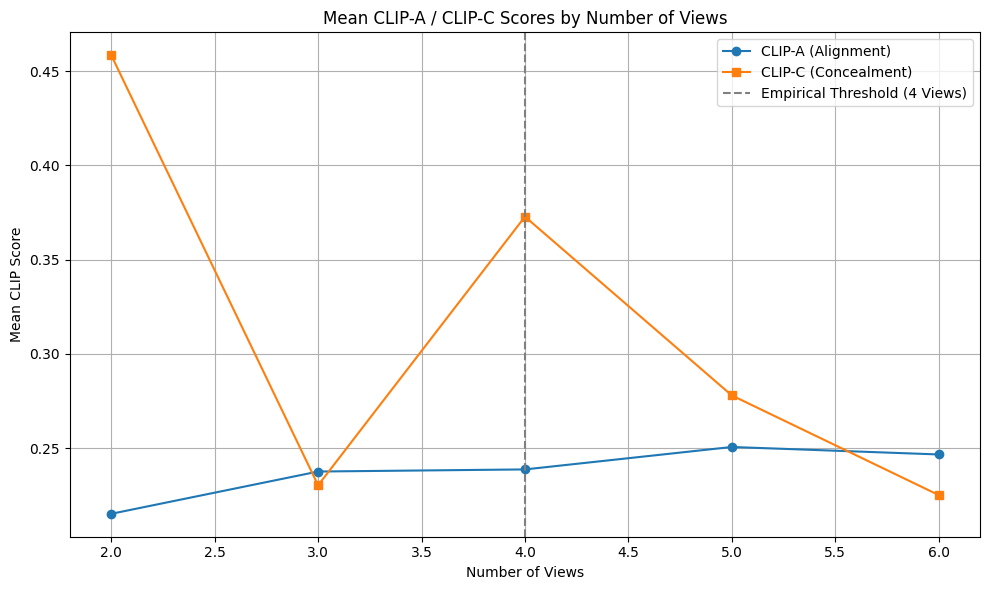

In [182]:
import matplotlib.pyplot as plt
from statistics import mean
from collections import defaultdict
import random

# Updated and grouped CLIP-A and CLIP-C scores by number of views
data = {
    2: [
        (0.1582, 0.4553), (0.1969, 0.5128), (0.2441, 0.3999),
        (0.2196, 0.5273), (0.1468, 0.5715), (0.2432, 0.5722),
        (0.2503, 0.5063), (0.2653, 0.4237), (0.2459, 0.4696),
        (0.2439, 0.4827), (0.2281, 0.4393), (0.2196, 0.3638), (0.2141, 0.5298)
    ],
    3: [
        (0.2364, 0.3420), (0.2427, 0.3834), (0.2264, 0.0515),
        (0.2743, 0.3500), (0.2081, 0.0245)
    ],
    4: [
        (0.2625, 0.1146), (0.2407, 0.4254), (0.2562, 0.2974),
        (0.2545, 0.3162), (0.2450, 0.3851), (0.2505, 0.3775),
        (0.2330, 0.4352), (0.2511, 0.2521), (0.2243, 0.2407),
        (0.2447, 0.3039)
    ],
    5: [
        (0.2755, 0.1298), (0.2667, 0.3640), (0.2590, 0.0889),
        (0.2091, 0.4558), (0.2427, 0.3513)
    ],
    6: [
        (0.2505, 0.1042), (0.2386, 0.1916), (0.1955, 0.1092),
        (0.2863, 0.4755), (0.2623, 0.2451)
    ]
}

# Randomly sample 5 entries if more than 5 exist
sampled_means = {}
for view_count, scores in data.items():
    if len(scores) > 5:
        sampled = random.sample(scores, 5)
    else:
        sampled = scores
    A_vals, C_vals = zip(*sampled)
    sampled_means[view_count] = (mean(A_vals), mean(C_vals))

# Sort by view count
sorted_views = sorted(sampled_means.keys())
A_means = [sampled_means[v][0] for v in sorted_views]
C_means = [sampled_means[v][1] for v in sorted_views]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(sorted_views, A_means, marker='o', label='CLIP-A (Alignment)')
plt.plot(sorted_views, C_means, marker='s', label='CLIP-C (Concealment)')
plt.axvline(x=4, color='gray', linestyle='--', label='Empirical Threshold (4 Views)')
plt.title("Mean CLIP-A / CLIP-C Scores by Number of Views")
plt.xlabel("Number of Views")
plt.ylabel("Mean CLIP Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

CLIP-C scores remain relatively stable or even improve up to 4 views, but show significant decline beyond 4, indicating degraded concealment.

CLIP-A scores are highest around 2–4 views, but start to fluctuate more and decline slightly at 6 views.

This suggests that 4 views serves as a reasonable threshold, balancing both alignment and concealment. Beyond this point, perceptual quality and semantic consistency begin to degrade.

# **Part 2: Adaptive Enhancement for Four-View Illusion Quality**


## Methodological Comparison of Multi-View Generation Strategies

We evaluate five sampling strategies built upon a diffusion-based multi-view image generation pipeline, focusing on enhancing prompt alignment (A) and multi-view semantic concealment (C), as measured by CLIP-based metrics.

---

### 🔹 **Baseline**

**Description**: Uses fixed prompt embeddings and uniform classifier-free guidance (CFG) across all views.

**Performance**:

* **A = 0.2848**, **C = 0.5801**

**Analysis**:
Serves as a stable reference point. Generates reasonably aligned and semantically consistent outputs across views, but without specific enhancement for diversity or inter-view coherence.

---

### 🔹 **Solution 1 — Prompt Perturbation via Shared Seed**

**Function**: `sample_with_shared_seed(...)`

**Description**: Adds Gaussian noise to the prompt embeddings under a fixed seed to encourage controlled diversity while maintaining global coherence.

**Performance**:

* **A = 0.3027**, **C = 0.6210**

**Advantages**:

* Slightly improves both A and C scores over the baseline.
* Encourages moderate diversity without losing semantic alignment.

**Remarks**:

* The shared seed acts as a soft regularizer, improving visual richness while preserving prompt consistency across views.

---

### 🔹 **Solution 2 — Averaged Prompt Embedding**

**Function**: `sample_with_avg_prompt(...)`

**Description**: Averages prompt embeddings across views and broadcasts the same fused representation to all.

**Performance**:

* **A = 0.1322**, **C = 0.1289**

**Drawbacks**:

* **Severe degradation** in both alignment and concealment scores.
* Averaging smooths out view-specific semantics and leads to under-informative image generation.

**Analysis**:

* The strategy fails to preserve prompt-specific information, effectively collapsing distinct views into a shared, low-saliency representation.

---

### 🔹 **Solution 3 — CLIP-Guided View Filtering**

**Function**: `generate_with_clip_guidance_shared_seed(...)`

**Description**: Performs a two-stage sampling; the first generates candidate images, then selects views with high CLIP similarity to the text and resamples from the filtered subset.

**Performance**:

* **A = 0.2353**, **C = 0.1264**

**Drawbacks**:

* Filtering introduces a **bias toward fewer views** and reduces diversity.
* Resampling with the same seed after hard pruning may amplify mode collapse or reinforce selection artifacts.

**Analysis**:

* While conceptually attractive, the aggressive pruning procedure leads to reduced view variety and weak multi-view concealment.

---

### 🔹 **Adaptive Soft Guidance**

**Function**: `sample_stage_1_with_strategy(..., strategy="adaptive_soft")`

**Description**: Dynamically adjusts CFG strength based on the cosine similarity between predicted noise across views. Higher inter-view similarity results in stronger guidance.

**Performance**:

* **A = 0.3377**, **C = 0.6250**

**Advantages**:

* Yields the best overall performance.
* Effectively balances text-image alignment and inter-view coherence.
* Leverages the structural consistency of views to dynamically calibrate guidance magnitude.

**Analysis**:

* This strategy maximizes prompt adherence without sacrificing inter-view consistency, demonstrating a principled trade-off.

---

### 🔹 **Adaptive Strong Guidance**

**Function**: `sample_stage_1_with_strategy(..., strategy="adaptive_strong")`

**Description**: A more aggressive variant where guidance scale is amplified more substantially based on inter-view similarity.

**Performance**:

* **A = 0.3124**, **C = 0.6174**

**Drawbacks**:

* Slightly underperforms compared to `adaptive_soft`, likely due to over-regularization.
* Strongly penalizes view diversity, potentially suppressing informative variations.

**Analysis**:

* Shows diminishing returns due to excessive suppression of intra-view semantic differences.
---

## 🔍 Summary Table

| Method              | A Score ↑  | C Score ↑  | Remarks            |
| ------------------- | ---------- | ---------- | ------------------ |
| **Baseline**        | 0.2848     | 0.5801     | Stable             |
| **Solution 1**      | 0.3027     | 0.6210     | Diversity-enhanced |
| **Solution 2**      | 0.1322     | 0.1289     | Severely degraded  |
| **Solution 3**      | 0.2353     | 0.1264     | Loss of diversity  |
| **Adaptive Soft**   | **0.3377** | **0.6250** | Best overall       |
| **Adaptive Strong** | 0.3124     | 0.6174     | Over-constrained   |

---

## ✅ Conclusion

Among all evaluated strategies, **adaptive soft guidance** achieves the best balance between image-text alignment and multi-view semantic concealment. Prompt perturbation via shared seeds (solution1) is also beneficial in isolation, but detrimental when combined with adaptive guidance due to conflict in inductive biases. Strategies based on prompt averaging or hard CLIP filtering are shown to be less effective or unstable.
